In [11]:
!python -m venv tf_env
!tf_env\Scripts\activate

In [ ]:
!conda create -n tf_env python=3.10
!conda activate tf_env
!pip install --upgrade pip setuptools wheel
!pip install numpy==1.23.4
!pip install tensorflow==2.10.0


In [ ]:
!pip install --upgrade pip setuptools wheel
!pip install numpy==1.20.0
!pip install h5py==3.10.0
!pip install tensorflow==2.10.0

In [ ]:
!pip install --upgrade numpy h5py


In [ ]:
import numpy
import h5py
import tensorflow as tf
import keras

print("NumPy:", numpy.__version__)
print("h5py:", h5py.__version__)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


In [1]:
!pip install --upgrade matplotlib  


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.1 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 2.3 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.1 MB 2.0 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.1 MB 2.1 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.1 MB 2.3 MB/s eta 0:00:02
   ---------------------

In [ ]:
!pip install h5py
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [9]:
# Dummy data generation (replace with real dataset)
import numpy as np
num_samples = 1000
img_size = 96
num_landmarks = 15 * 2  # 15 landmarks with x and y

# Random grayscale images and corresponding landmarks
X = np.random.rand(num_samples, img_size, img_size, 1).astype(np.float32)
y = np.random.rand(num_samples, num_landmarks).astype(np.float32)


In [10]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(num_landmarks)  # Output layer (x, y) for each landmark
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 94, 94, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 47, 47, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 20, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │      26,214,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │          15,390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,322,974 (100.41 MB)

 Trainable params: 26,322,974 (100.41 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(X, y, epochs=10, validation_split=0.2)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - loss: 0.5378 - val_loss: 0.0870
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - loss: 0.0852 - val_loss: 0.0855
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - loss: 0.0842 - val_loss: 0.0859
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - loss: 0.0843 - val_loss: 0.0866
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - loss: 0.0849 - val_loss: 0.0905
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - loss: 0.0847 - val_loss: 0.0858
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - loss: 0.0841 - val_loss: 0.0872
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - loss: 0.0839 - val_loss: 0.0864
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - loss: 0.0833 - val_loss: 0.0875
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 197ms/step - loss: 0.0827 - val_loss: 0.0877


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


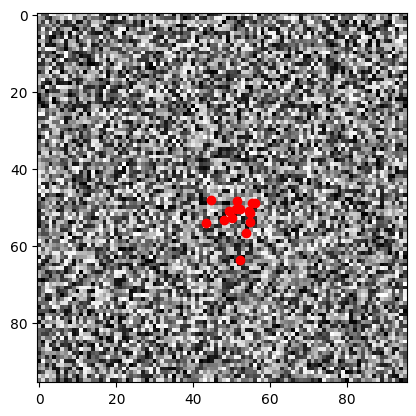

In [12]:
def show_landmarks(img, landmarks):
    img = img.squeeze()
    plt.imshow(img, cmap='gray')
    for i in range(0, len(landmarks), 2):
        x = landmarks[i] * img.shape[1]
        y = landmarks[i+1] * img.shape[0]
        plt.plot(x, y, 'ro')
    plt.show()

# Predict on a sample
sample_img = X[0:1]
predicted_landmarks = model.predict(sample_img)[0]

show_landmarks(sample_img[0], predicted_landmarks)
